In [1]:
import pandas as pd
import os
import numpy as np
import ast
import collections
from pygenomeviz import GenomeViz
import ast
import pysam

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
    "pdf.fonttype": 42,  
    "ps.fonttype": 42,   
    "svg.fonttype": "none"  
})

mpl.rcParams["font.family"] = "Arial"

In [3]:
myDF2=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/DAZNames_PSV.csv").set_index("Unnamed: 0")
myDF2['end']=[int(x.split("-")[1]) for x in myDF2.index]

In [4]:
colorDict={'DAZ1_EXON1':'pink',
    'DAZ1_EXON2-7-12':'lightblue',
            'DAZ1_EXON3-8-13':'black',
            'DAZ1_EXON4-9-14':'red',
            'DAZ1_EXON5-10-15':'green',
            'DAZ1_EXON6-11-16':'purple',
           'DAZ1_EXON17':'yellow',
            'DAZ1_EXON18':'yellow',
           'DAZ1_EXON19':'yellow',
           'DAZ1_EXON20-22':'yellow',
           'DAZ1_EXON21':'yellow',
           'DAZ1_EXON23':'yellow',
           'DAZ1_EXON24':'yellow',
           'DAZ1_EXON25':'yellow',
           'DAZ1_EXON26':'lime',
           'DAZ1_EXON27':'grey',
           'DAZ1_EXON28':'blue',   
}

In [5]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [6]:
from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [7]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [8]:
haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

In [9]:
for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

140


In [2]:
#QC checked good AZFc regions
errDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv").drop(columns=['Unnamed: 0'])

In [4]:
len(set(errDF['sample']))

100

In [11]:
hgsvc = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_07162025.csv')
hprc = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HPRC_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_06162025.csv')
ceph = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/CEPH_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_09092025.csv')


dazDFCEPH = ceph[ceph['geneName']=='DAZ1'].copy()
dazDFCEPH['Consortia']="CEPH"
dazDFCEPH['contigStart']=dazDFCEPH['contigStart'].astype(int)
dazDFCEPH['contigEnd']=dazDFCEPH['contigEnd'].astype(int)
dazDFCEPH.sort_values(by=['contig','contigStart'], inplace=True)

dazDFHGSVC = hgsvc[hgsvc['geneName']=='DAZ1'].copy()
dazDFHGSVC['Consortia']="HGSVC"
dazDFHGSVC['contigStart']=dazDFHGSVC['contigStart'].astype(int)
dazDFHGSVC['contigEnd']=dazDFHGSVC['contigEnd'].astype(int)
dazDFHGSVC.sort_values(by=['contig','contigStart'], inplace=True)

dazDFHPRC = hprc[hprc['geneName']=='DAZ1'].copy()
dazDFHPRC['Consortia']="HPRC"
dazDFHPRC['contigStart']=dazDFHPRC['contigStart'].astype(int)
dazDFHPRC['contigEnd']=dazDFHPRC['contigEnd'].astype(int)
dazDFHPRC.sort_values(by=['contig','contigStart'], inplace=True)

In [12]:
combinedDAZ0 = pd.concat([dazDFHPRC,dazDFHGSVC,dazDFCEPH])
combinedDAZ1 = combinedDAZ0[~combinedDAZ0['contig'].str.contains("random")].copy()
combinedDAZ = combinedDAZ1[combinedDAZ1['sampleName'].isin(set(errDF['sample']))].copy()

print(len(combinedDAZ1))
print(len(combinedDAZ))
combinedDAZ.reset_index(inplace=True)

505
382


In [13]:
assemblyDict={}
directory='/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'
for file in os.listdir(directory):
    if '.fai' in file or '.gzi' in file or '.DS' in file:
        continue
    else:
        assemblyDict[file.split("_")[0]]= directory+file
print(len(assemblyDict))

143


In [15]:
letterExonDict={'17':'B', '18':'C','19':'D','20-22':'E','21':'F','23':'X','24':'Y','25':'Z'}

In [16]:
import ast
for row in combinedDAZ.index:
    exonList = ast.literal_eval(str(combinedDAZ.at[row,'Exons']))
    for exon in exonList:
        if exon[9].split("EXON")[1] == '17' and float(exon[1]) != 0.0:
            print(exon)
        else:
            continue 

['641', '1.4', '0.0', '0.0', 'HG00126_chrY', 24095817, 24095888, '(28421907)', '+', 'DAZ1_EXON17', 'Unspecified', '1', '72', '(0)', '13993', 'HG00126', 'V2_Assembly', 'DAZ1_Copy_2', 'Full_Exon_Copy', 'DAZ1', 0.0608695652173913]
['639', '1.4', '0.0', '0.0', 'HG00290_chrY', 24479782, 24479853, '(34388656)', '+', 'DAZ1_EXON17', 'Unspecified', '1', '72', '(0)', '13809', 'HG00290', 'V2_Assembly', 'DAZ1_Copy_2', 'Full_Exon_Copy', 'DAZ1', 0.05185185185185185]
['641', '1.4', '0.0', '0.0', 'HG002_chrY', 25671686, 25671757, '(36740490)', '+', 'DAZ1_EXON17', 'Unspecified', '1', '72', '(0)', '14990', 'HG002', 'V2_Assembly', 'DAZ1_Copy_4', 'Full_Exon_Copy', 'DAZ1', 0.06363636363636363]
['641', '1.4', '0.0', '0.0', 'HG00329_chrY', 24103976, 24104047, '(31986350)', '+', 'DAZ1_EXON17', 'Unspecified', '1', '72', '(0)', '13557', 'HG00329', 'V2_Assembly', 'DAZ1_Copy_2', 'Full_Exon_Copy', 'DAZ1', 0.05185185185185185]
['641', '1.4', '0.0', '0.0', 'HG00609_chrY', 24378956, 24379027, '(47567217)', 'C', 'DAZ1

## RepeatMasker

In [17]:
rmDict={}
directory="/LeeLab/HPRC/chromosomeY/Data/RepeatMasker/"
for file in os.listdir(directory):
    rmDict[file.split(".")[0]]=directory+file
print(len(rmDict))

146


In [18]:
repeatList=[]
for sample in set(combinedDAZ['sampleName']):

    rmDF = pd.read_csv(rmDict[sample], sep='\t')
    
    sampleDF = combinedDAZ[combinedDAZ['sampleName']==sample].copy()
    for row in sampleDF.index:
        contig = str(sampleDF.at[row,'contig'])
        start = int(sampleDF.at[row,'contigStart'])
        end = int(sampleDF.at[row,'contigEnd'])

        subRMDF = rmDF[(rmDF['query_match_start']>=start) & (rmDF['query_match_end']<=end) & (rmDF['query_name']==contig)].copy()
        subRMDF['sample']=sample
        repeatList.append(subRMDF)

rmCombined = pd.concat(repeatList)

In [19]:
colorRepeatDict={}
for x in set(rmCombined['repeat_class_family']):
    if 'DNA' in x:
        colorRepeatDict[x]='blue'
    elif 'LTR' in x:
        colorRepeatDict[x]='yellow'

    elif 'LINE' in x:
        colorRepeatDict[x]='orange'

    elif 'SINE' in x:
        colorRepeatDict[x]='red'

    elif 'Simple' in x or 'Low' in x:
        colorRepeatDict[x]='brown'

    elif 'SVA' in x:
        colorRepeatDict[x]='cyan'
    else:
        colorRepeatDict[x]='pink'

In [20]:
contigSizes=[]
for row in combinedDAZ.index:
    exons = ast.literal_eval(str(combinedDAZ.at[row,'Exons']))
    contigSizes.append(exons[0][7].split("(")[1].split(")")[0])
combinedDAZ['ContigSizeRemaining']=contigSizes               

In [21]:
len(set(combinedDAZ['sampleName']))

100

In [22]:
dazExonDFList=[]
for sample in phylogeneticOrder:
    print(sample)
        
    tempDF = combinedDAZ[combinedDAZ['sampleName']==sample].copy()

    for contig in set(tempDF['contig']):

        tempDF2 = tempDF[tempDF['contig']==contig].copy()
        orderList =[]
        for row in tempDF2.index:
            rnaBinding={'DAZ1_EXON2-7-12':0,
                    'DAZ1_EXON3-8-13':0,
                    'DAZ1_EXON4-9-14':0,
                    'DAZ1_EXON5-10-15':0,
                    'DAZ1_EXON6-11-16':0,
                   }
            
            for exon in ast.literal_eval(str(tempDF2.at[row,'Exons'])):
                if exon[9] in rnaBinding:
                    rnaBinding[exon[9]]+=1
                else:
                    continue

            minValue = min(rnaBinding, key=rnaBinding.get)
            orderList.append(rnaBinding[minValue])

        print(sample, contig, orderList)
        dazExonDFList.append([sample, contig, orderList])

HG02984
HG01890
HG01890 HG01890_chrY [1, 2, 1, 3]
HG02647
HG02666
HG02666 HG02666_chrY [3, 1, 1, 2]
HG02668
HG03225
HG03225 HG03225_chrY [3, 1, 1, 2]
NA19043
NA19384
HG005
HG005 HG005_chrY [3, 1]
NA18952
NA18952 NA18952_chrY [3, 1]
NA18983
NA18983 NA18983_chrY [1, 3]
HG02572
HG02572 HG02572_chrY [3, 1, 2, 1]
HG03248
HG03248 HG03248_chrY [3, 1, 2, 1]
HG03098
HG03050
NA19239
NA19239 NA19239_chrY [3, 1, 2, 1]
HG01074
HG01074 HG01074_chrY [3, 1, 2, 2]
HG01109
HG01109 HG01109_chrY [3, 1, 2, 2]
HG01106
NA19331
NA19331 NA19331_chrY [3, 1, 2, 1]
HG01252
HG01252 HG01252_chrY [3, 1, 1, 2]
HG01457
HG01457 HG01457_chrY [1, 3, 1, 2]
HG03065
HG03065 HG03065_chrY [1, 2, 1, 3, 1, 2]
HG02717
HG02717 HG02717_chrY [3, 1, 1, 2]
HG03471
HG03471 HG03471_chrY [1, 2, 1, 3]
HG02011
HG02011 HG02011_chrY [3, 1, 1, 2]
HG03371
HG03371 HG03371_chrY [3, 1, 1, 2]
HG02486
HG02965
HG02965 HG02965_chrY [3, 1, 1, 2]
HG03139
HG03139 HG03139_chrY [3, 1, 1, 2]
NA19443
NA19443 NA19443_chrY [3, 1, 1, 2]
NA19317
NA19317 NA1931

In [23]:
exondazDF = pd.DataFrame(data=dazExonDFList, columns=['sample','contig','exonList'])
#exondazDF.to_csv('/LeeLab/HPRC/chromosomeY/Data/HGSVC3_HPRC_CEPH_DAZ_RRM_CopyNumbers_09152025.csv')

In [24]:
len(set(exondazDF['sample']))

100

In [25]:
letterExonDict={'17':'B', '18':'C','19':'D','20-22':'E','21':'F','23':'X','24':'Y','25':'Z'}

In [26]:
import ast
import pandas as pd

sizes={}
contigSizeInformation = {}
visualizeSamples = ()
genome_geneList = []
orientationDict = {'+': 1, 'C': -1}
gap = 5000  

for sample in phylogeneticOrder:

    if sample not in list(combinedDAZ['sampleName']):
        continue

    tempDF = combinedDAZ[combinedDAZ['sampleName'] == sample].copy()
    tempRMDF = rmCombined[rmCombined['sample'] == sample].copy()
    for contig_id in tempDF['contig'].unique():

        contigDAZ = tempDF[tempDF['contig'] == contig_id].copy()
        contigRM = tempRMDF[tempRMDF['query_name'] == contig_id].copy()

        newTempList = []
        RowCount = 1

        for row in contigDAZ.index:
            start = contigDAZ.at[row, 'contigStart']
            end = contigDAZ.at[row, 'contigEnd']
            orientation = orientationDict[contigDAZ.at[row, 'orientation']]

            exonList = ast.literal_eval(str(contigDAZ.at[row, 'Exons']))
            for exon in exonList:
                exonNumber = exon[9].split("EXON")[1]
                if exonNumber in letterExonDict:
                    if exonNumber == '17' and float(exon[1])>0.0:
                        label='A'
                    else:
                        label = letterExonDict[exonNumber]
                else:
                    if str(exon[1]) == '0.0':
                        label=''
                    else:
                        label = str(exon[1])
                newTempList.append([
                    exon[4],                
                    exon[5],             
                    exon[6],               
                    1,                      
                    label,                   
                    f'block_{RowCount}',    
                    colorDict[exon[9]],exon[9], exon[8]
                ])

            blockRM = contigRM[
                (contigRM['query_match_start'] >= start) &
                (contigRM['query_match_end']   <= end)
            ].copy()

            for rrow in blockRM.index:
                newTempList.append([
                    str(blockRM.at[rrow, 'query_name']),       
                    int(blockRM.at[rrow, 'query_match_start']),
                    int(blockRM.at[rrow, 'query_match_end']),
                    -1,
                    str(blockRM.at[rrow, 'repeat_class_family']),
                    f'block_{RowCount}',
                    colorRepeatDict[blockRM.at[rrow, 'repeat_class_family']], 'Repeat', str(blockRM.at[rrow,'match_orientation'])
                ])

            RowCount += 1

        if not newTempList:
            continue

        newCombinedDFTemp = pd.DataFrame(data=newTempList).sort_values(by=[1])
        min_start = newCombinedDFTemp[1].min()
        newCombinedDFTemp['NewStart'] = newCombinedDFTemp[1] - (min_start - 1)
        newCombinedDFTemp['NewEnd']   = newCombinedDFTemp[2] - (min_start - 1)

        unique_blocks = set(newCombinedDFTemp[5])

        if len(unique_blocks) == 4:
            block2 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_2'].copy()
            block3 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_3'].copy()

            secondBlockEnd   = block2['NewEnd'].max()
            thirdBlockStart  = block3['NewStart'].min()

            desired_third_start = secondBlockEnd + gap
            shift34 = thirdBlockStart - desired_third_start

            blockGroup12 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_1', 'block_2'])].copy()
            blockGroup34 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_3', 'block_4'])].copy()

            blockGroup34['NewStart'] = blockGroup34['NewStart'] - shift34
            blockGroup34['NewEnd']   = blockGroup34['NewEnd']   - shift34

            newDF = pd.concat([blockGroup12, blockGroup34], ignore_index=True)

        elif len(unique_blocks) == 6:
            block2 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_2'].copy()
            block3 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_3'].copy()
            block4 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_4'].copy()

            blockGroup12 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_1', 'block_2'])].copy()
            blockGroup34 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_3', 'block_4'])].copy()
            blockGroup56 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_5', 'block_6'])].copy()

            secondBlockEnd  = block2['NewEnd'].max()
            thirdBlockStart = block3['NewStart'].min()

            desired_third_start = secondBlockEnd + gap
            shift34 = thirdBlockStart - desired_third_start

            blockGroup34['NewStart'] = blockGroup34['NewStart'] - shift34
            blockGroup34['NewEnd']   = blockGroup34['NewEnd']   - shift34

            shifted_block4 = blockGroup34[blockGroup34[5] == 'block_4']
            shifted_block4_end = shifted_block4['NewEnd'].max()

            desired_fifth_start = shifted_block4_end + gap
            current_fifth_start = blockGroup56[blockGroup56[5] == 'block_5']['NewStart'].min()

            shift56 = current_fifth_start - desired_fifth_start

            blockGroup56['NewStart'] = blockGroup56['NewStart'] - shift56
            blockGroup56['NewEnd']   = blockGroup56['NewEnd']   - shift56

            newDF = pd.concat([blockGroup12, blockGroup34, blockGroup56], ignore_index=True)

        else:
            newDF = newCombinedDFTemp

        count=0
        newDF['PSV']='NONE'
        myDazPSVList = list(myDF2[myDF2['contig']==list(newDF[0])[0]].sort_values(by=['start'])['MaxCount'])
        exon1Only = newDF[newDF[7]=='DAZ1_EXON1'].copy()
        for row in exon1Only.index:
            try:
                newDF.at[row,'PSV']=myDazPSVList[count]
                count+=1
            except:
                continue
    
        if len(unique_blocks) == 3 or 'random' in contig_id:
            continue
        else:
            sizes[f"{sample}|{contig_id}"]=max(newDF['NewEnd'])
            genome_geneList.append({
                "name": f"{sample}|{contig_id}",
                "df": newDF,
                'haplogroup':haplogroups[sample]
            })


In [27]:
len(sizes)

100

In [28]:
len(genome_geneList)

100

In [29]:
badSamplesDontUse=['NA12883','NA12884','HG03456']

In [30]:
gv = GenomeViz(fig_track_height=0.25, feature_track_ratio=.9)
gv.set_scale_xticks(ymargin=0.5)

by_sample = {}
for item in genome_geneList:
    name = item["name"]
    if name in badSamplesDontUse:
        continue
    else:
        if "|" in name:
            sample, contig_id = name.split("|", 1)
        else:
            sample, contig_id = name, name
        by_sample.setdefault(sample, []).append(item)

tracks = {}

for sample in phylogeneticOrder:
    if sample not in by_sample or sample in badSamplesDontUse or sample+"_chrY" not in set(myDF2['contig']):
        continue

    for item in sorted(by_sample[sample], key=lambda d: d["name"].split("|", 1)[1]):
        full_name = item["name"]
        haplogroup = item['haplogroup']
        sample_id, contig_id = full_name.split("|", 1)
        tempDF = item["df"]

        if contig_id in sizes:
            contig_len = sizes[contig_id]
        else:
            contig_len = int(tempDF["NewEnd"].max())

        track = gv.add_feature_track(
            contig_id+"\n"+haplogroup,
            contig_len,
            labelsize=8
        )
        tracks[contig_id+"\n"+haplogroup] = track

        for row in tempDF.index:
            start = int(tempDF.at[row, "NewStart"])
            end   = int(tempDF.at[row, "NewEnd"])
            flag  = tempDF.at[row, 3]
            color = tempDF.at[row, 6]
            label=tempDF.at[row, 4]
            psvLabel = tempDF.at[row, 'PSV']
            designation = tempDF.at[row, 7]

            plotstyle = "box"

            if designation =='Repeat':
                track.add_feature(
                    start,
                    end,
                    flag,
                    plotstyle=plotstyle,
                    facecolor=color
                )
            else:
                if designation == 'DAZ1_EXON1':
                    if tempDF.at[row,8] == 'C':
                            track.add_feature(
                            start,
                            end,
                            flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=str(psvLabel)+":\n<-",
                            text_kws=dict(rotation=0, vpos="top", hpos="left", size=5)
                        )
                    else:
                        track.add_feature(
                            start,
                            end,
                            flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=str(psvLabel)+":\n->",
                            text_kws=dict(rotation=0, vpos="top", hpos="right", size=5)
                        )

                else:
                    if color == 'yellow':
                        track.add_feature(
                                start,
                                end,
                                flag,
                                plotstyle=plotstyle,
                                facecolor=color,
                                label=label,
                                text_kws=dict(rotation=0, vpos="top", hpos="center", size=5)
                            )
                    else:
                        track.add_feature(
                                start,
                                end,
                                flag,
                                plotstyle=plotstyle,
                                label=label,
                                facecolor=color,
                                text_kws=dict(rotation=0, vpos="top", hpos="center", size=3)
                            )                

gv.savefig("/DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026.pdf")

global_size: 421829
Saved /DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page1.pdf
Saved /DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page2.pdf
Saved /DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page3.pdf


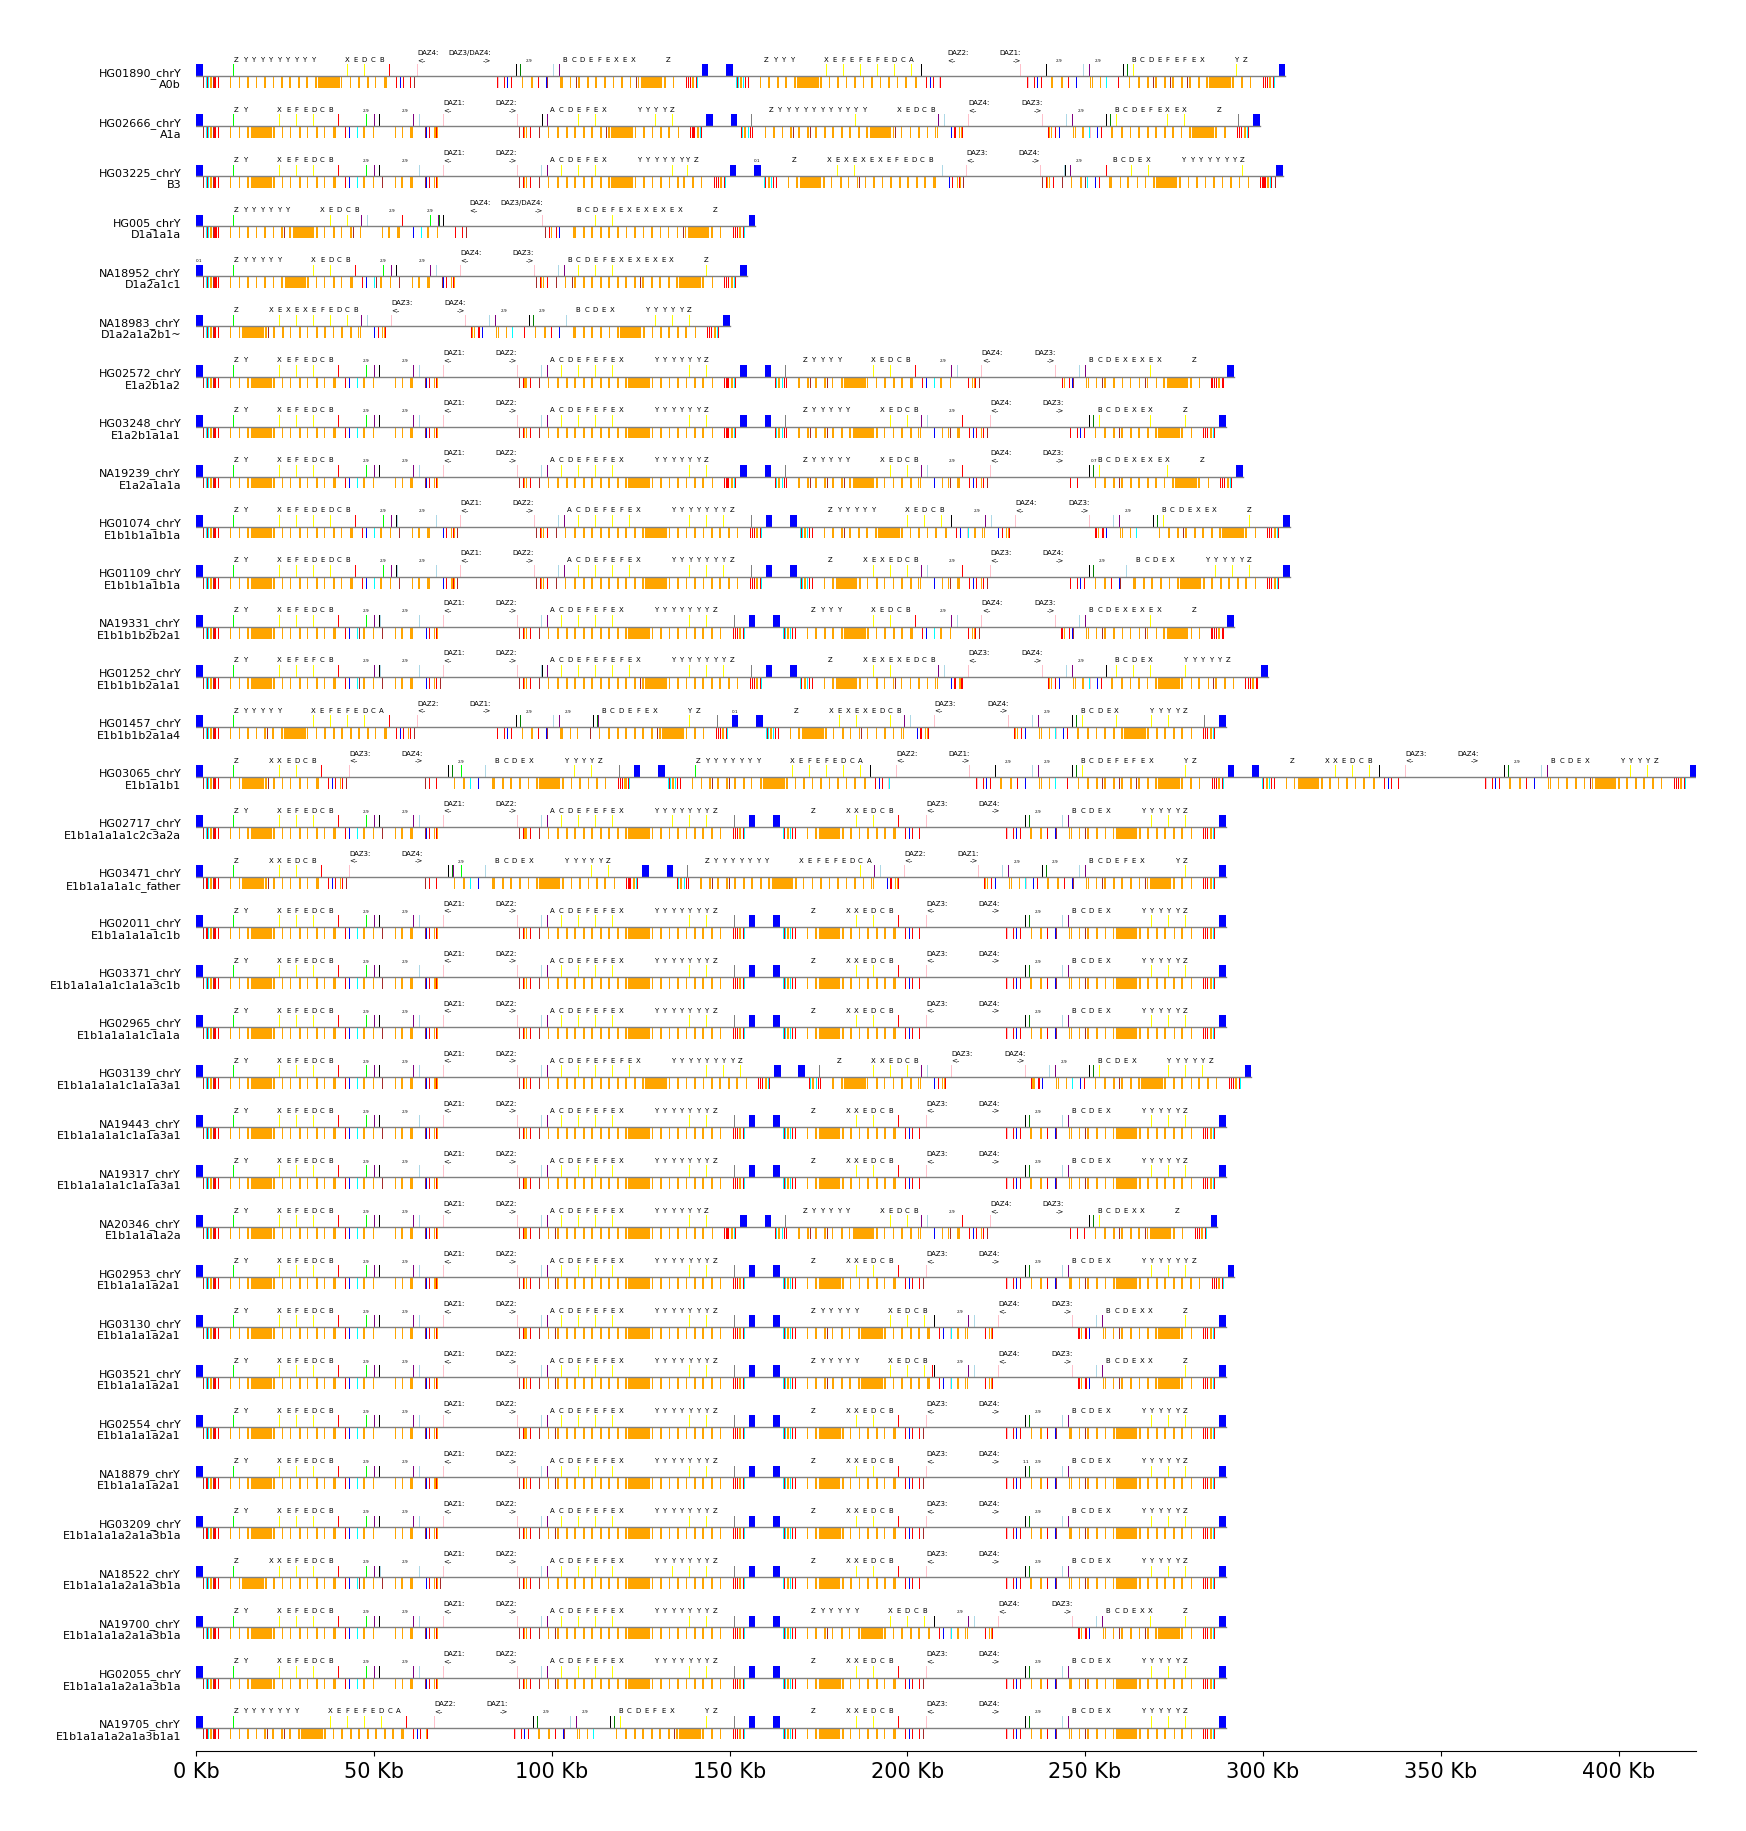

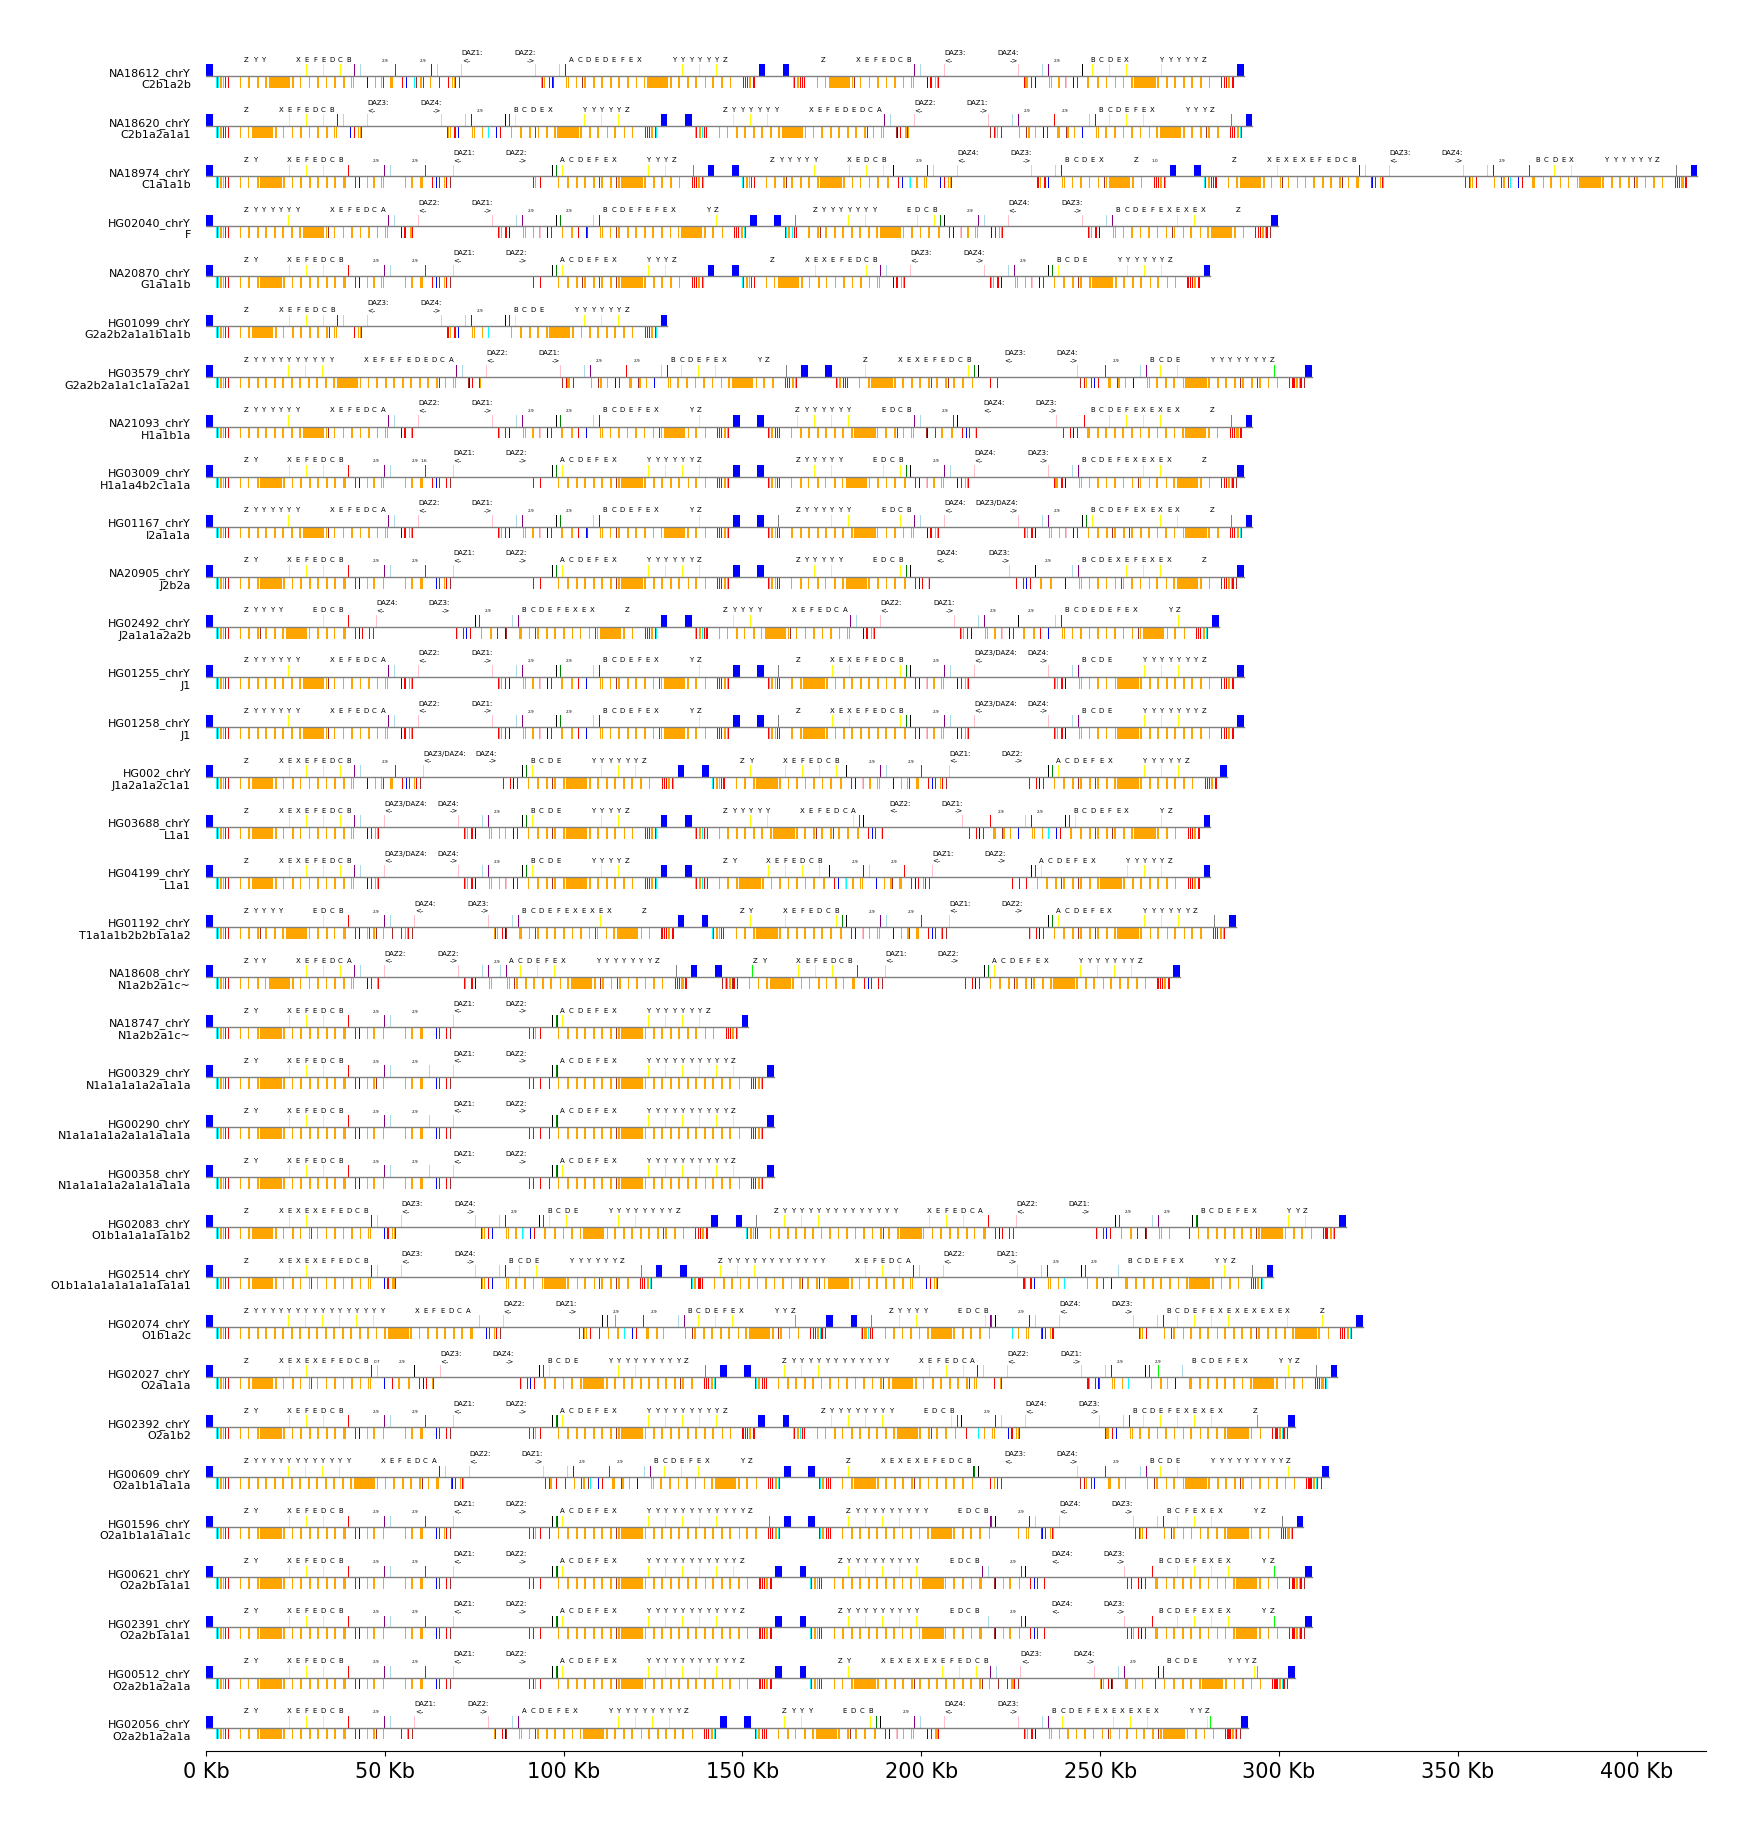

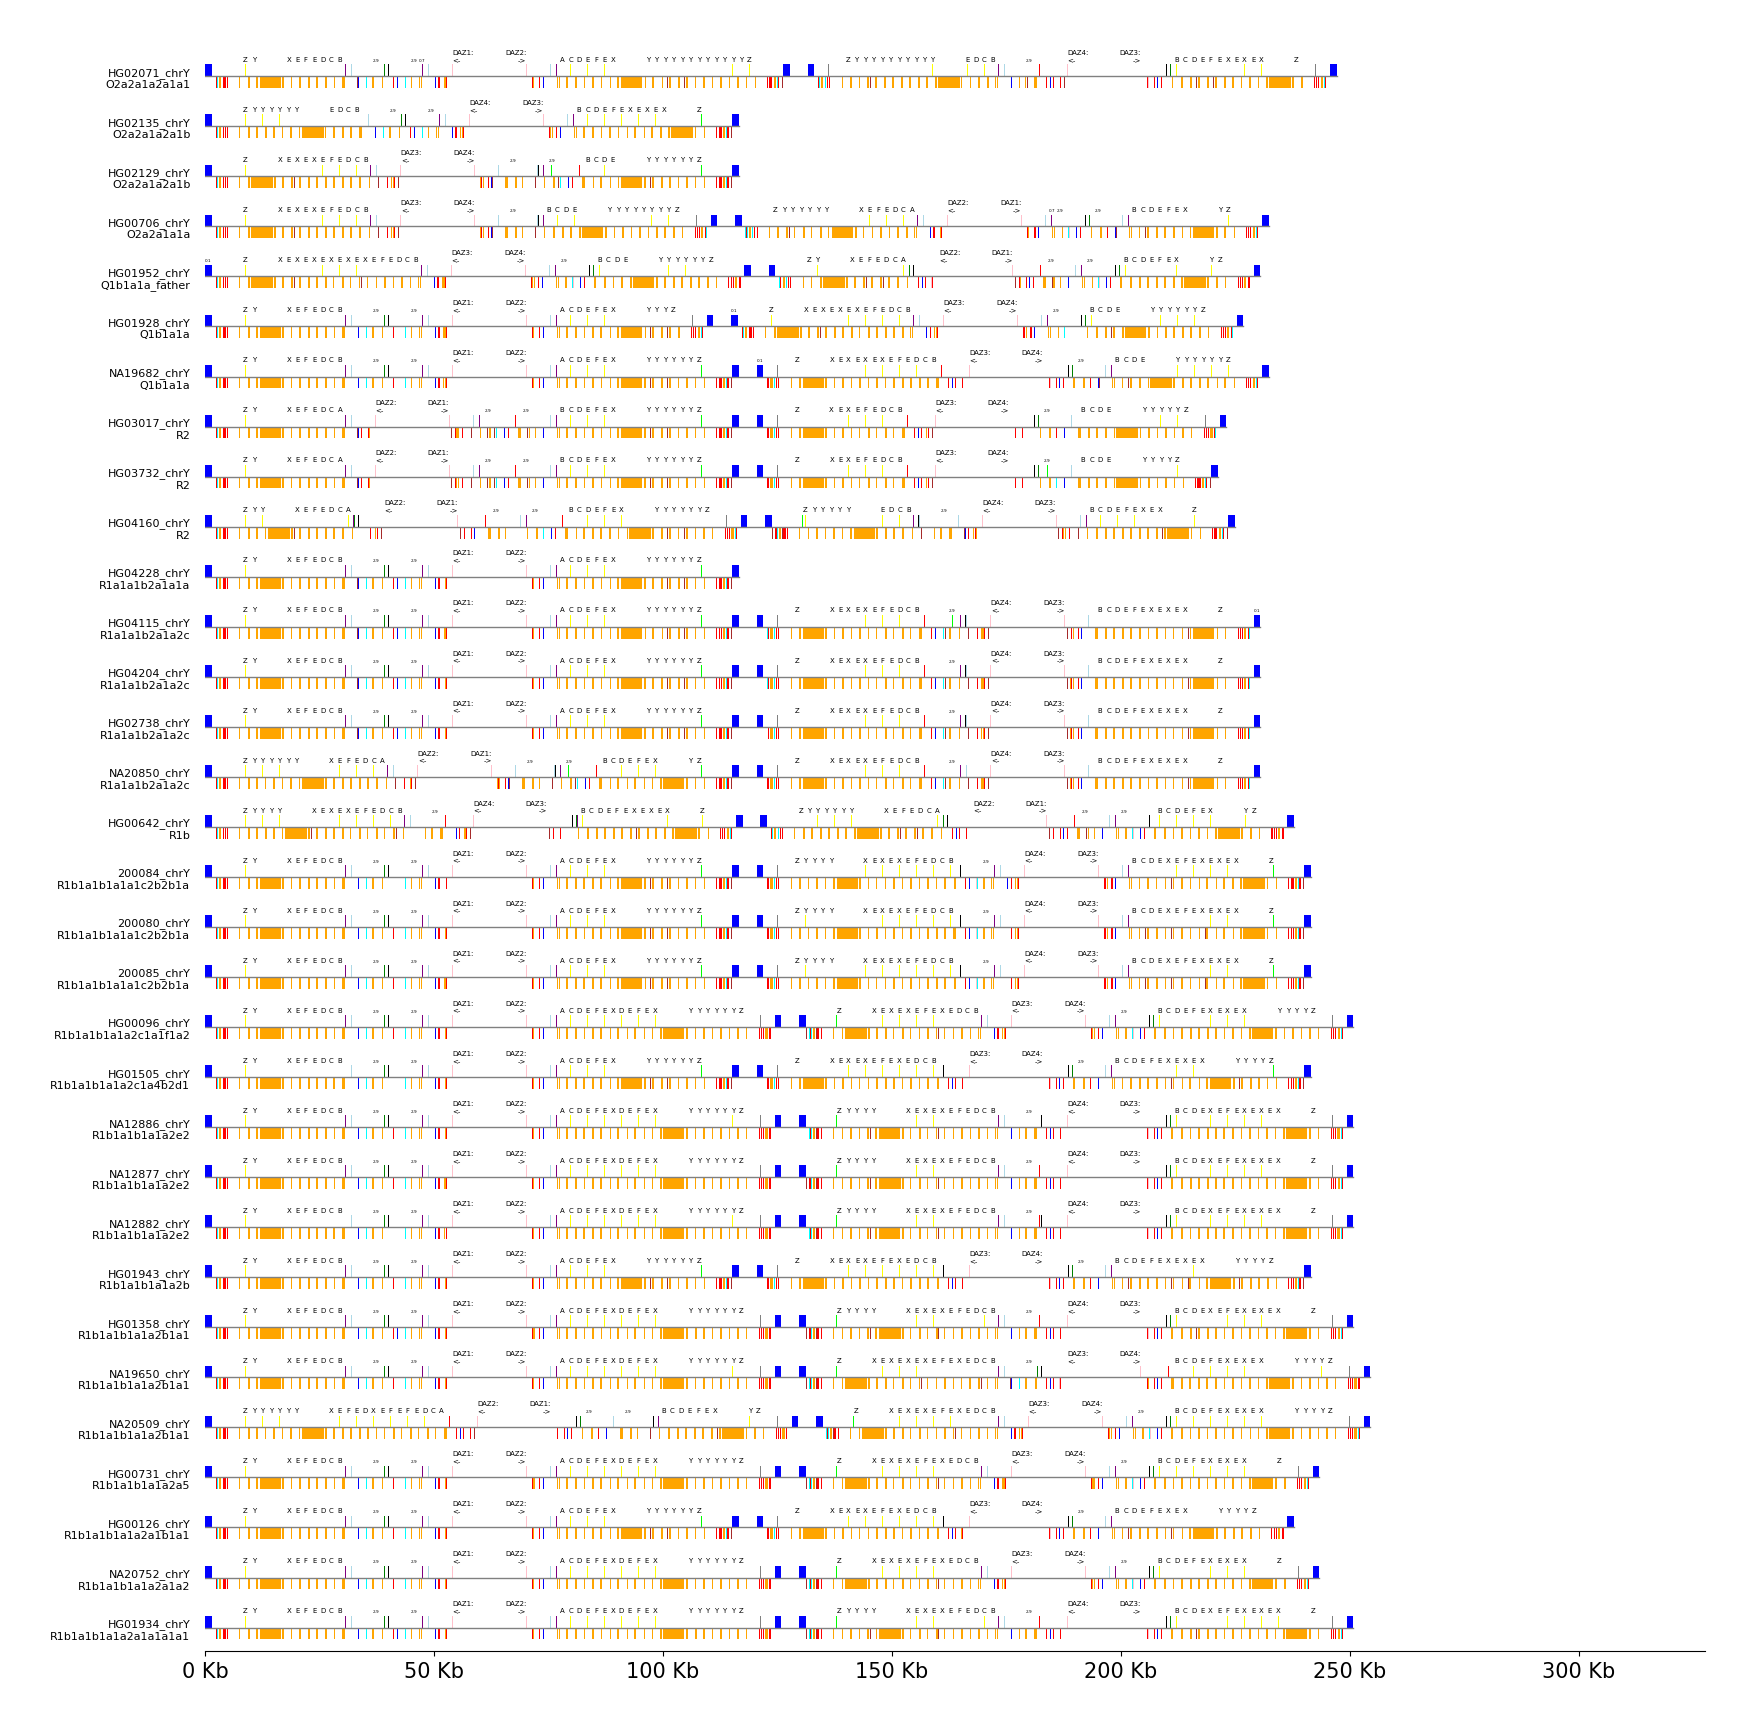

In [32]:
import math
from pygenomeviz import GenomeViz

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


dbgapssamples = {'NA12883', 'NA12884'}

by_sample = {}
for item in genome_geneList:
    name = item["name"] 
    if name in badSamplesDontUse:
        continue

    if "|" in name:
        sample, contig_id = name.split("|", 1)
    else:
        sample, contig_id = name, name

    by_sample.setdefault(sample, []).append(item)

ordered_specs = []

for sample in phylogeneticOrder:
    if sample in dbgapssamples:
        continue
    if sample not in by_sample:
        continue
    if sample in badSamplesDontUse:
        continue
    if (sample + "_chrY") not in set(myDF2["contig"]):
        continue

    for item in sorted(by_sample[sample], key=lambda d: d["name"].split("|", 1)[1]):
        full_name = item["name"]                
        haplogroup = item["haplogroup"]
        sample_id, contig_id = full_name.split("|", 1)
        tempDF = item["df"]

        if contig_id in sizes:
            contig_len = int(sizes[contig_id])
        else:
            contig_len = int(tempDF["NewEnd"].max())

        track_label = contig_id + "\n" + haplogroup

        feats = []
        for row in tempDF.index:
            start = int(tempDF.at[row, "NewStart"])
            end   = int(tempDF.at[row, "NewEnd"])
            flag  = tempDF.at[row, 3]
            color = tempDF.at[row, 6]
            label = tempDF.at[row, 4]
            psvLabel = tempDF.at[row, "PSV"]
            designation = tempDF.at[row, 7]

            feats.append({
                "start": start,
                "end": end,
                "flag": flag,
                "color": color,
                "label": label,
                "psvLabel": psvLabel,
                "designation": designation,
                "extra": {
                    "col8": tempDF.at[row, 8] if 8 in tempDF.columns else None
                }
            })

        ordered_specs.append({
            "track_label": track_label,
            "contig_len": contig_len,
            "features": feats,
        })


global_size = max((spec["contig_len"] for spec in ordered_specs), default=1)
print("global_size:", global_size)


Npages = 3
per_fig = math.ceil(len(ordered_specs) / Npages) if ordered_specs else 1

for page_idx, spec_chunk in enumerate(chunks(ordered_specs, per_fig), start=1):

    gv = GenomeViz(fig_track_height=0.25, feature_track_ratio=0.9)
    gv.set_scale_xticks(ymargin=0.5)
    for spec in spec_chunk:
        track_label = spec["track_label"]
        contig_len  = spec["contig_len"]

        track = gv.add_feature_track(
            track_label,
            contig_len,
            labelsize=8,
        )

        for f in spec["features"]:
            start = f["start"]
            end   = f["end"]
            flag  = f["flag"]
            color = f["color"]
            label = f["label"]
            psvLabel = f["psvLabel"]
            designation = f["designation"]

            plotstyle = "box"

            if designation == "Repeat":
                track.add_feature(
                    start, end, flag,
                    plotstyle=plotstyle,
                    facecolor=color
                )
            else:
                if designation == "DAZ1_EXON1":
                    col8 = f["extra"]["col8"]
                    if col8 == "C":
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=str(psvLabel) + ":\n<-",
                            text_kws=dict(rotation=0, vpos="top", hpos="left", size=5)
                        )
                    else:
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=str(psvLabel) + ":\n->",
                            text_kws=dict(rotation=0, vpos="top", hpos="right", size=5)
                        )

                else:
                    if color == "yellow":
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=label,
                            text_kws=dict(rotation=0, vpos="top", hpos="center", size=5)
                        )
                    else:
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=label,
                            text_kws=dict(rotation=0, vpos="top", hpos="center", size=3)
                        )


    fig = gv.plotfig()
    for ax in fig.axes:
        if ax.has_data():
            ax.set_xlim(0, global_size)

    out_pdf = f"/DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page{page_idx}.pdf"
    out_jpg = f"/DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page{page_idx}.jpg"
    fig.savefig(out_pdf)
    fig.savefig(out_jpg, dpi=300)
    print("Saved", out_pdf)


global_size: 421829
Saved /DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page1.pdf
Saved /DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page2.pdf
Saved /DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page3.pdf


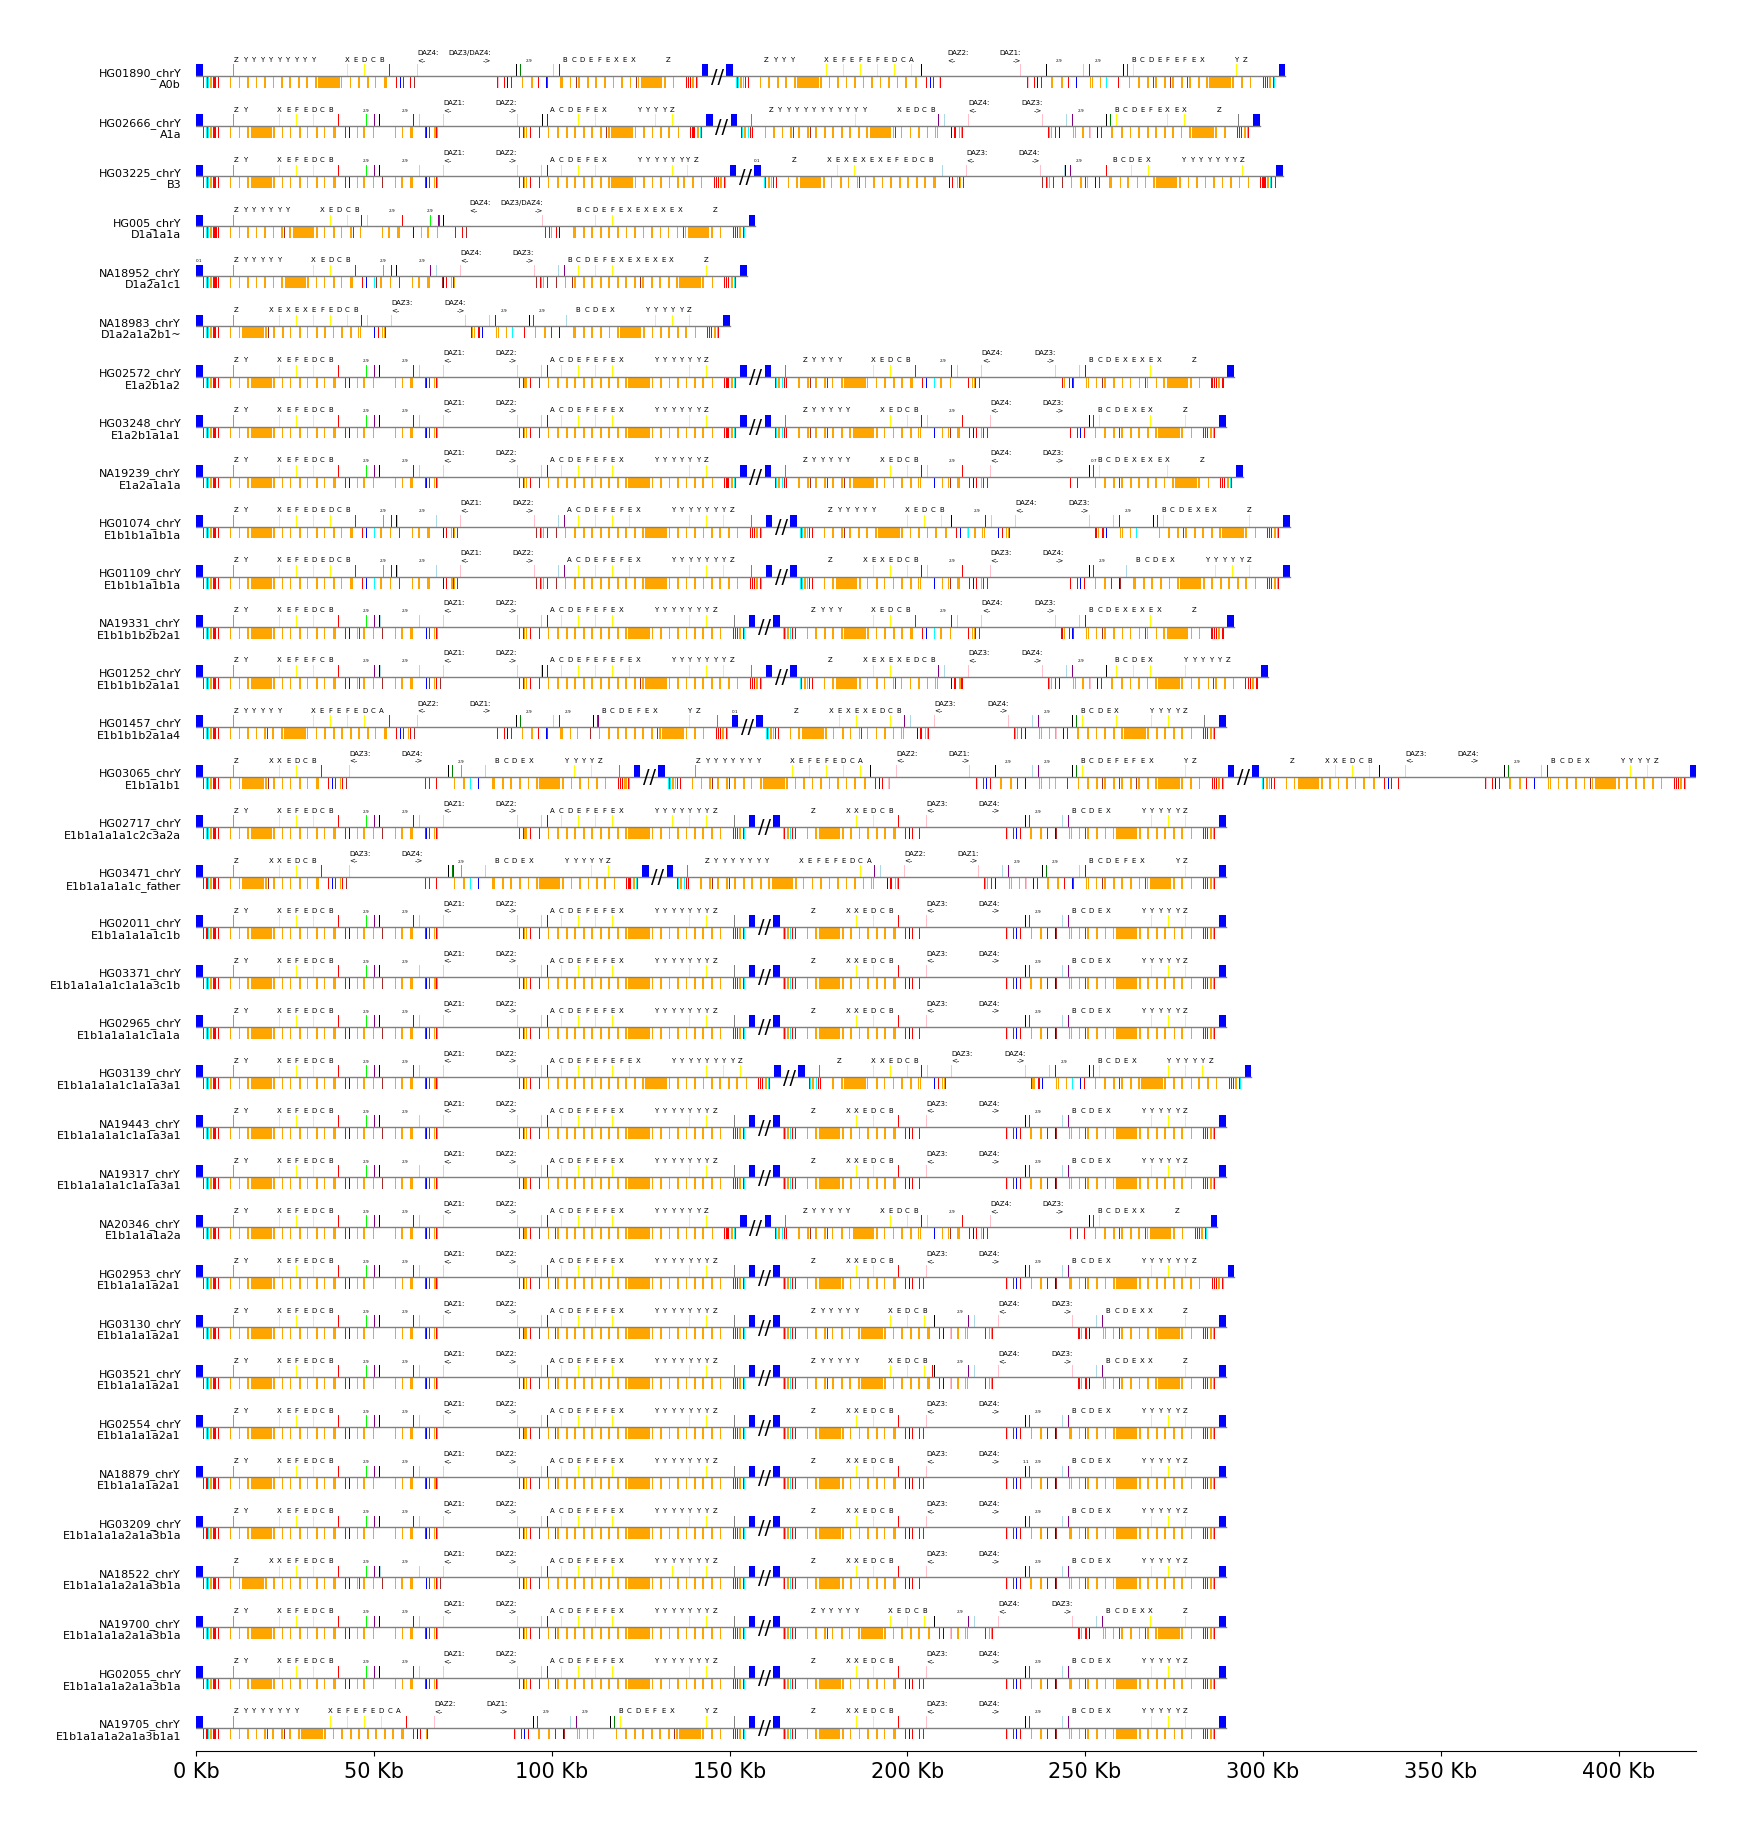

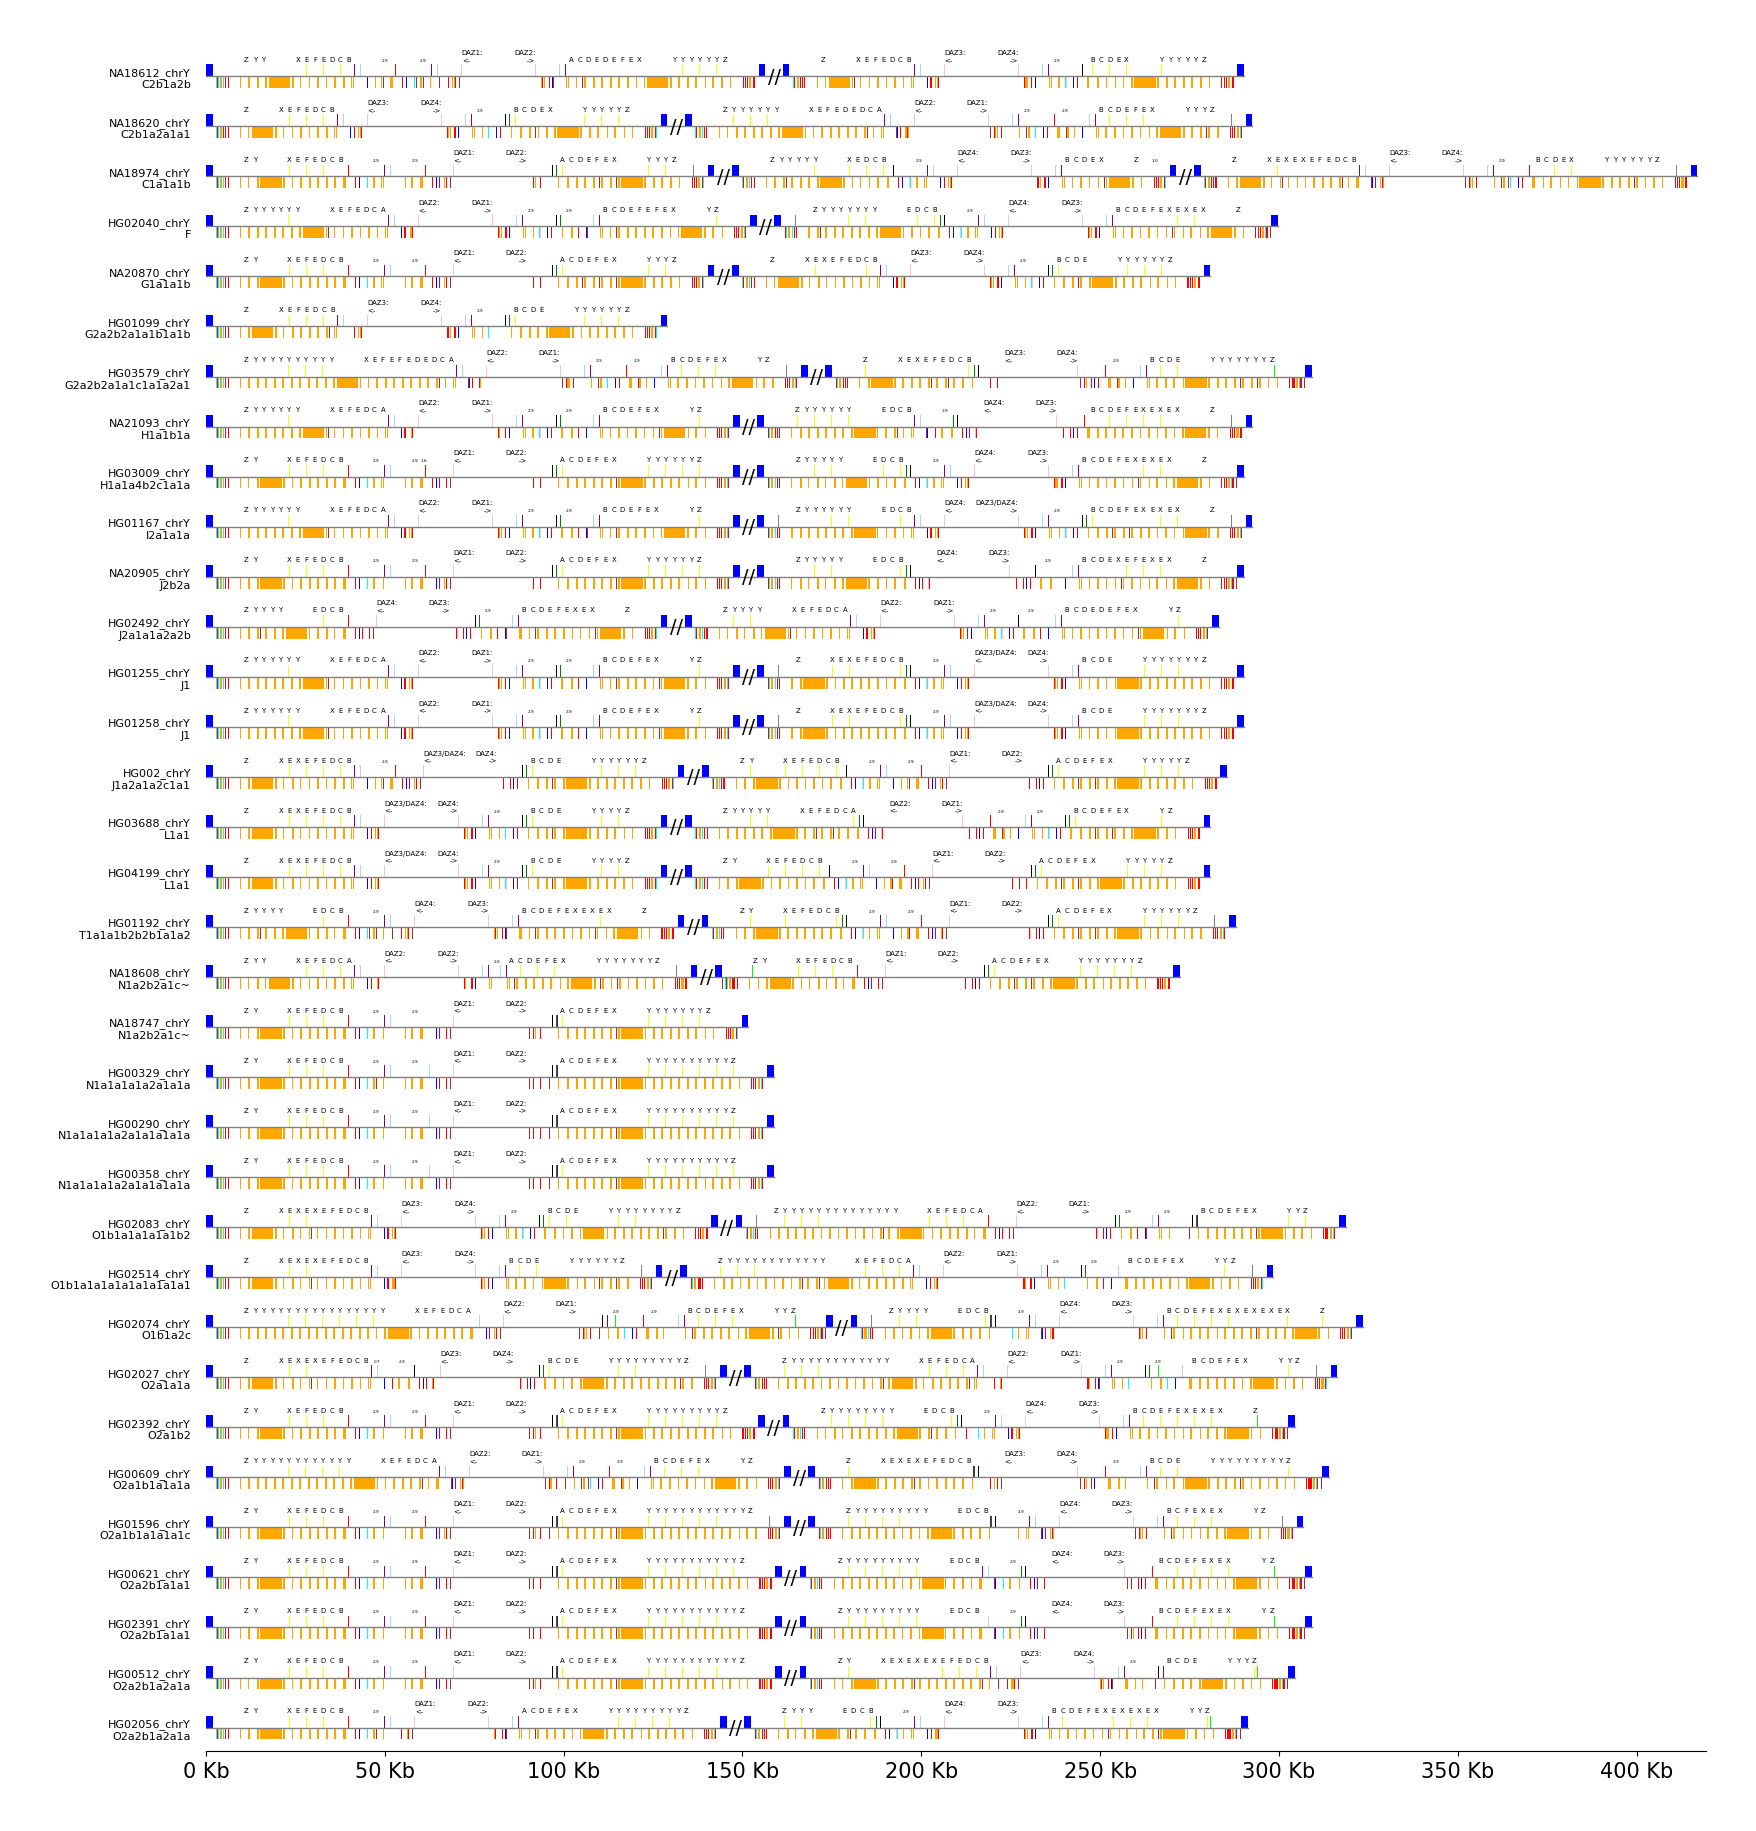

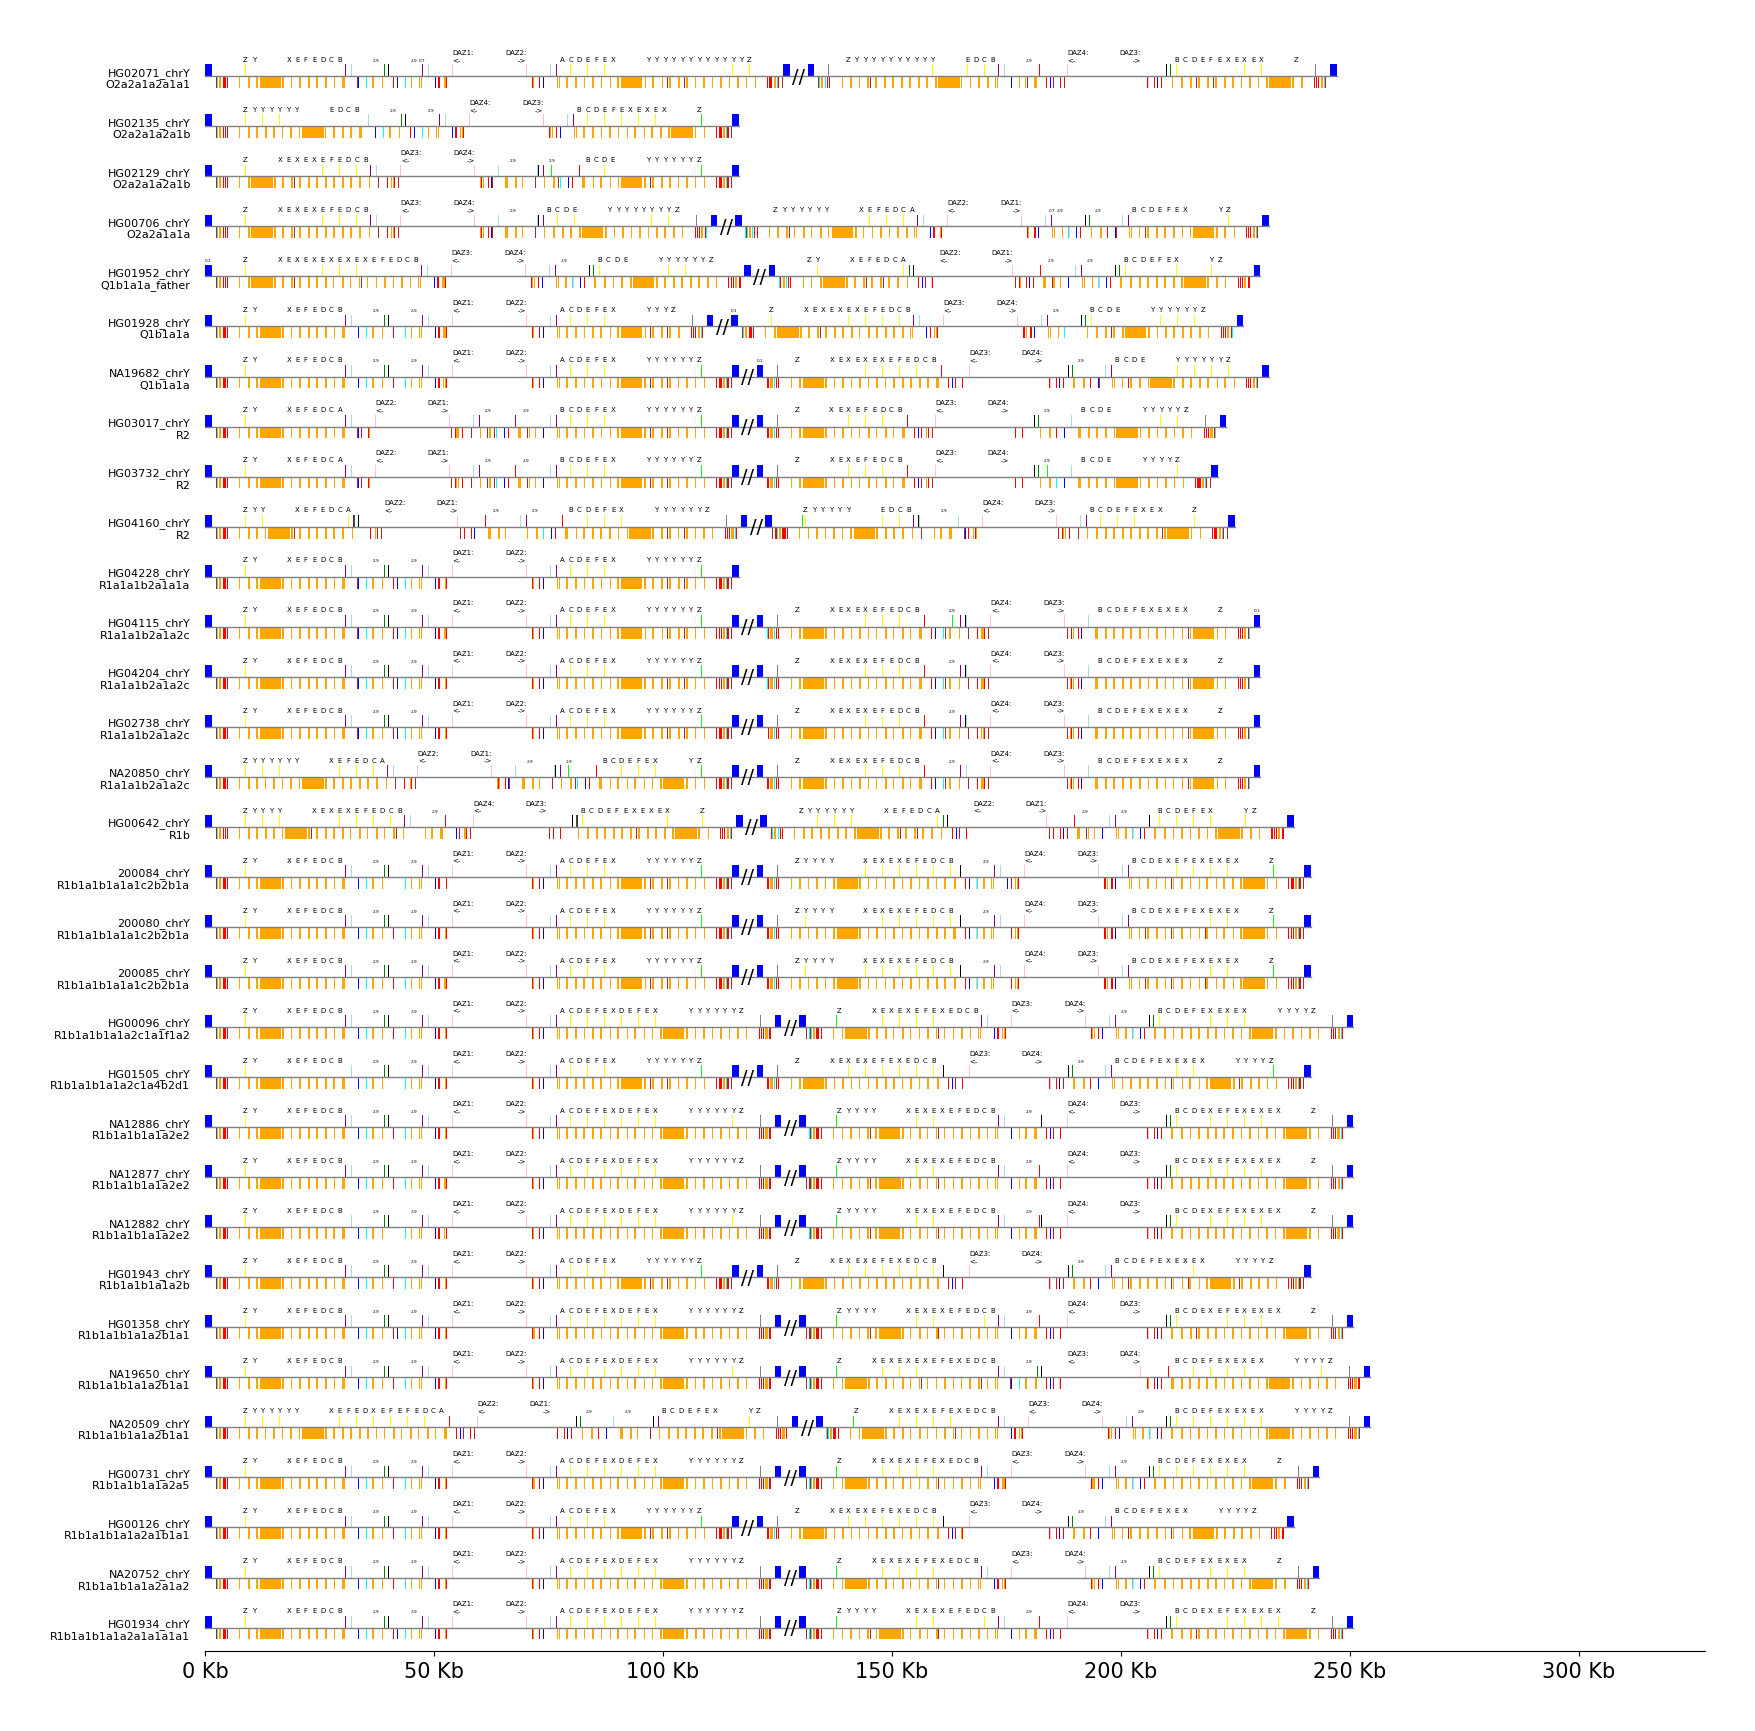

In [40]:
import math
from pygenomeviz import GenomeViz

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]


dbgapssamples = {'NA12883', 'NA12884'}


MARK_DESIGNATION = "DAZ1_EXON28"
MARK_EVERY = 2
MARK_SHIFT_BP = 2500       
MARK_TEXT_SIZE = 14         
MARK_BOX_WIDTH = 2        

by_sample = {}
for item in genome_geneList:
    name = item["name"]  
    if name in badSamplesDontUse:
        continue

    if "|" in name:
        sample, contig_id = name.split("|", 1)
    else:
        sample, contig_id = name, name

    by_sample.setdefault(sample, []).append(item)


ordered_specs = []

for sample in phylogeneticOrder:
    if sample in dbgapssamples:
        continue
    if sample not in by_sample:
        continue
    if sample in badSamplesDontUse:
        continue
    if (sample + "_chrY") not in set(myDF2["contig"]):
        continue

    for item in sorted(by_sample[sample], key=lambda d: d["name"].split("|", 1)[1]):
        full_name = item["name"]
        haplogroup = item["haplogroup"]
        sample_id, contig_id = full_name.split("|", 1)
        tempDF = item["df"]

        if contig_id in sizes:
            contig_len = int(sizes[contig_id])
        else:
            contig_len = int(tempDF["NewEnd"].max())

        track_label = contig_id + "\n" + haplogroup

        feats = []
        daz28_count = 0

        for row in tempDF.index:
            start = int(tempDF.at[row, "NewStart"])
            end   = int(tempDF.at[row, "NewEnd"])
            flag  = tempDF.at[row, 3]
            color = tempDF.at[row, 6]
            label = tempDF.at[row, 4]
            psvLabel = tempDF.at[row, "PSV"]
            designation = tempDF.at[row, 7]

            feats.append({
                "kind": "feature",
                "start": start,
                "end": end,
                "flag": flag,
                "color": color,
                "label": label,
                "psvLabel": psvLabel,
                "designation": designation,
                "extra": {
                    "col8": tempDF.at[row, 8] if 8 in tempDF.columns else None
                }
            })


            if designation == MARK_DESIGNATION:
                daz28_count += 1

                if MARK_EVERY > 0 and (daz28_count % MARK_EVERY == 0):
                    mstart = end + 1 + MARK_SHIFT_BP
                    mend   = mstart + MARK_BOX_WIDTH

                    if mstart < contig_len:
                        feats.append({
                            "kind": "marker",
                            "start": mstart,
                            "end": min(mend, contig_len),
                            "flag": 1,
                            "label": "//",
                        })

        ordered_specs.append({
            "track_label": track_label,
            "contig_len": contig_len,
            "features": feats,
        })


global_size = max((spec["contig_len"] for spec in ordered_specs), default=1)
print("global_size:", global_size)


Npages = 3
per_fig = math.ceil(len(ordered_specs) / Npages) if ordered_specs else 1

for page_idx, spec_chunk in enumerate(chunks(ordered_specs, per_fig), start=1):

    gv = GenomeViz(fig_track_height=0.25, feature_track_ratio=0.9)
    gv.set_scale_xticks(ymargin=0.5)

    for spec in spec_chunk:
        track_label = spec["track_label"]
        contig_len  = spec["contig_len"]

        track = gv.add_feature_track(
            track_label,
            contig_len,
            labelsize=8,
        )

        for f in spec["features"]:
            if f.get("kind") == "marker":
                track.add_feature(
                    f["start"], f["end"], f["flag"],
                    plotstyle="box",
                    facecolor="none",
                    lw=0,
                    label=f["label"],
                    text_kws=dict(rotation=0, vpos="center", hpos="center", size=MARK_TEXT_SIZE)
                )
                continue

            start = f["start"]
            end   = f["end"]
            flag  = f["flag"]
            color = f["color"]
            label = f["label"]
            psvLabel = f["psvLabel"]
            designation = f["designation"]

            plotstyle = "box"

            if designation == "Repeat":
                track.add_feature(
                    start, end, flag,
                    plotstyle=plotstyle,
                    facecolor=color
                )
            else:
                if designation == "DAZ1_EXON1":
                    col8 = f["extra"]["col8"]
                    if col8 == "C":
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=str(psvLabel) + ":\n<-",
                            text_kws=dict(rotation=0, vpos="top", hpos="left", size=5)
                        )
                    else:
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=str(psvLabel) + ":\n->",
                            text_kws=dict(rotation=0, vpos="top", hpos="right", size=5)
                        )
                else:
                    if color == "yellow":
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=label,
                            text_kws=dict(rotation=0, vpos="top", hpos="center", size=5)
                        )
                    else:
                        track.add_feature(
                            start, end, flag,
                            plotstyle=plotstyle,
                            facecolor=color,
                            label=label,
                            text_kws=dict(rotation=0, vpos="top", hpos="center", size=3)
                        )

    fig = gv.plotfig()
    for ax in fig.axes:
        if ax.has_data():
            ax.set_xlim(0, global_size)

    out_pdf = f"/DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page{page_idx}.pdf"
    out_jpg = f"/DAZ_CEPH-HGSVC-HPRC_Exons_Jan222026_page{page_idx}.jpg"
    fig.savefig(out_pdf)
    fig.savefig(out_jpg, dpi=300)
    print("Saved", out_pdf)
